# 🛒 Sentiment Analysis — Tokopedia Food & Drink Reviews

> **Classifying customer sentiment from Tokopedia product reviews using Multinomial Naive Bayes**

---

## 📌 Project Overview

This project builds an end-to-end **NLP sentiment analysis pipeline** on real-world Indonesian e-commerce data. Customer reviews from Tokopedia's Food & Drink category are preprocessed, vectorized, and classified into **Positive** or **Negative** sentiment using a **Multinomial Naive Bayes** classifier.

| | |
|---|---|
| **Domain** | Natural Language Processing (NLP) |
| **Task** | Binary Text Classification |
| **Algorithm** | Multinomial Naive Bayes |
| **Language** | Indonesian |
| **Dataset** | [Tokopedia Product Reviews — Food & Drink](https://www.kaggle.com/datasets/kulitekno/tokopedia-product-review-category-food-and-drink) |

---

## 🗂️ Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Text Preprocessing Pipeline](#3-text-preprocessing-pipeline)
4. [Sentiment Labeling & Class Balancing](#4-sentiment-labeling--class-balancing)
5. [Vectorization (Bag of Words)](#5-vectorization-bag-of-words)
6. [Model Training — Multinomial Naive Bayes](#6-model-training)
7. [Model Evaluation](#7-model-evaluation)
8. [Inference on New Data](#8-inference-on-new-data)
9. [Conclusion](#9-conclusion)

---
## 1. Setup & Imports

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import re

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ── Plot Style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


---
## 2. Data Loading & Exploration

In [2]:
df = pd.read_csv('reviewTokped.csv')

print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {list(df.columns)}")
print()
df.head()

Dataset shape  : (5428, 3)
Columns        : ['Unnamed: 0', 'Review', 'Rating']



,Unnamed: 0,Review,Rating
0,0,maaantap,5
1,1,Enak & segar,5
2,2,maknyus,5
3,3,Dari berat 500 gram yg remuk 59 gram.\nEntah d...,4
4,4,"enak banget, fresh dan renyah!",5


In [3]:
# ── Data types & null check ────────────────────────────────────────────────────
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5428 entries, 0 to 5427
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5428 non-null   int64 
 1   Review      5123 non-null   object
 2   Rating      5428 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 127.3+ KB

Missing values per column:
Unnamed: 0      0
Review        305
Rating          0
dtype: int64


/tmp/ipykernel_299/2418755293.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d', ax=ax)


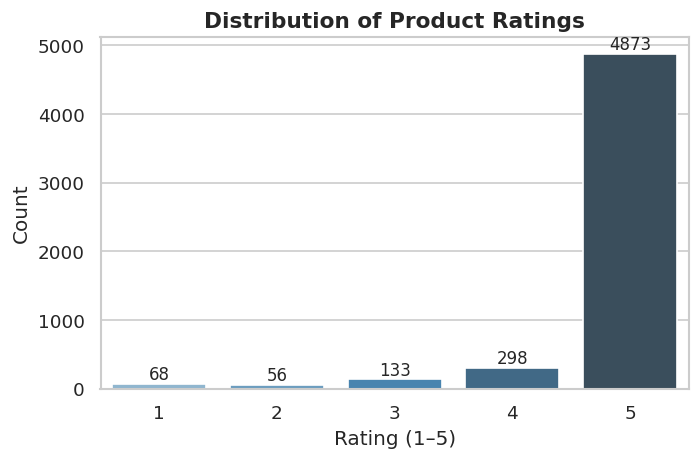

In [4]:
# ── Rating distribution ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
rating_counts = df['Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d', ax=ax)

for bar, val in zip(ax.patches, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_title('Distribution of Product Ratings', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating (1–5)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Key observations:**
- The dataset is heavily skewed toward **Rating 5**, which is typical for e-commerce platforms.
- This class imbalance needs to be addressed before modeling.

---
## 3. Text Preprocessing Pipeline

Raw text data contains noise that can degrade model performance. The preprocessing steps below clean and normalize the reviews before they are fed into the model.

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Drop unused index column | Removes artifact from CSV export |
| 2 | Strip whitespace characters (`\t`, `\n`, `\r`) | Normalizes spacing |
| 3 | Remove emojis & non-ASCII symbols | Focuses on textual signal |
| 4 | Lowercase conversion | Reduces vocabulary size |
| 5 | Remove punctuation & special chars | Keeps only alphanumeric tokens |
| 6 | Collapse multiple spaces | Cleans up post-strip artifacts |
| 7 | Remove duplicate rows | Prevents data leakage |
| 8 | Reset index | Ensures clean integer index |

In [5]:
def preprocess_text(df: pd.DataFrame) -> pd.DataFrame:
    """Apply full text preprocessing pipeline to the Review column."""
    df = df.copy()

    # Step 1 — Drop unnamed index column
    df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

    # Step 2 — Strip whitespace characters
    df.replace(
        to_replace=[r"\t|\n|\r", "\t|\n|\r"],
        value=[" ", " "],
        regex=True,
        inplace=True
    )

    # Step 3 — Remove emojis & non-ASCII symbols
    df['Review'] = df['Review'].str.replace(
        r'[^\w\s#@/:%.,_-]', '', flags=re.UNICODE, regex=True
    )

    # Step 4 — Lowercase
    df['Review'] = df['Review'].str.lower()

    # Step 5 — Remove punctuation & special characters
    df['Review'] = df['Review'].str.replace(r'[^\w\s]', ' ', regex=True)

    # Step 6 — Collapse multiple spaces & strip edges
    df['Review'] = df['Review'].str.replace(r' {2,}', ' ', regex=True).str.strip()

    # Step 7 — Remove duplicates
    df.drop_duplicates(keep=False, inplace=True)

    # Step 8 — Reset index
    df.reset_index(drop=True, inplace=True)

    return df


df = preprocess_text(df)

print(f"✅ Preprocessing complete. Dataset shape after cleaning: {df.shape}")
print()

# Verify no nulls remain
print("Missing values after preprocessing:")
print(df.isnull().sum())

✅ Preprocessing complete. Dataset shape after cleaning: (4060, 2)

Missing values after preprocessing:
Review    0
Rating    0
dtype: int64


In [6]:
# Preview cleaned data
df.head(10)

,Review,Rating
0,enak kuacinya,5
1,pengiriman cepat packing bagus sesuai pesanan ...,5
2,pengemasan luar biasa baik untuk rasa menurut ...,4
3,terimakasih min,5
4,udah order untuk kesekian kali jos,5
5,enaak dan guriih kacangnya,5
6,respon cepat harga terjangkau,5
7,mantappppp recommended empingnya enakkkkk,5
8,mantapppp puas kali gurih bnget entr mau pesan...,5
9,kondisi baik kurir baik mdh2an enak terimakasih,5


---
## 4. Sentiment Labeling & Class Balancing

### 4.1 Assign Sentiment Labels

Sentiment is derived from the `Rating` column using the following rule:

| Rating | Label | Sentiment |
|--------|-------|-----------|
| 1 – 3  | `0`   | Negative  |
| 4 – 5  | `1`   | Positive  |

In [7]:
df['Sentiment'] = df['Rating'].apply(lambda x: 0 if x <= 3 else 1)

sentiment_counts = df['Sentiment'].value_counts()
print("Sentiment distribution before balancing:")
print(sentiment_counts.rename({0: 'Negative (0)', 1: 'Positive (1)'}))

Sentiment distribution before balancing:
Sentiment
Positive (1)    3829
Negative (0)     231
Name: count, dtype: int64


### 4.2 Downsample the Majority Class

The Positive class significantly outnumbers the Negative class. To prevent the model from being biased toward the majority class, we **downsample** the Positive class to match the Negative class count.

In [8]:
min_samples = sentiment_counts.min()
print(f"Minimum class count: {min_samples} — downsampling Positive class to this size.")

# Randomly remove excess Positive samples
positive_idx = df[df['Sentiment'] == 1].index.to_series().sample(frac=1, random_state=RANDOM_STATE)
df = df.drop(positive_idx[min_samples:])
df.reset_index(drop=True, inplace=True)

balanced_counts = df['Sentiment'].value_counts()
print(f"\n✅ Dataset balanced. New shape: {df.shape}")

Minimum class count: 231 — downsampling Positive class to this size.

✅ Dataset balanced. New shape: (462, 3)


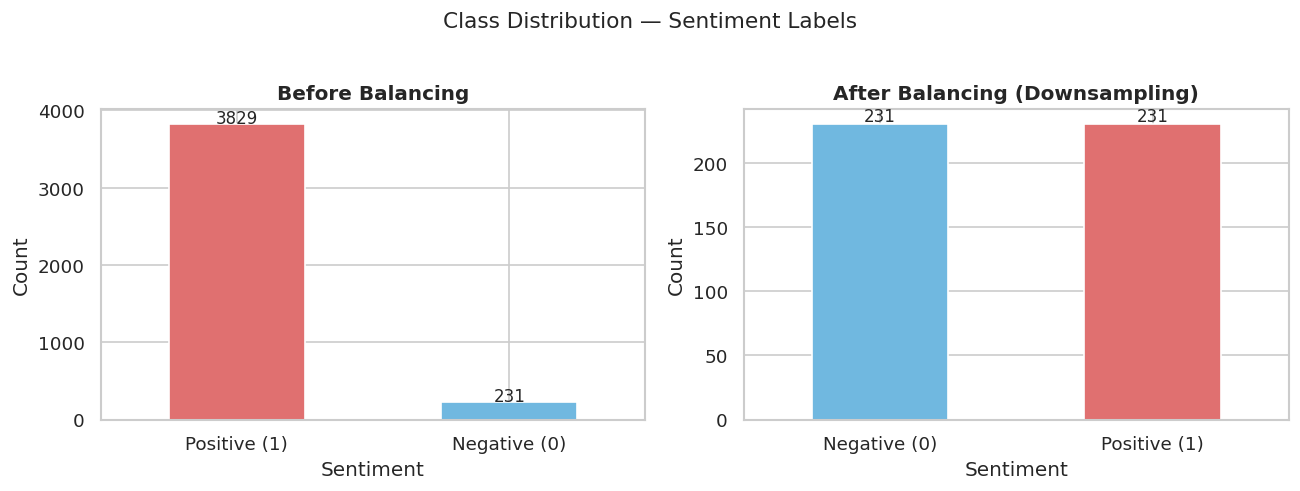

In [9]:
# ── Visualize balanced distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Before balancing
colors = ['#e07070', '#70b8e0']
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, rot=0)
axes[0].set_title('Before Balancing', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Positive (1)', 'Negative (0)'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', fontsize=10)

# After balancing
balanced_counts.sort_index().plot(kind='bar', ax=axes[1], color=list(reversed(colors)), rot=0)
axes[1].set_title('After Balancing (Downsampling)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', fontsize=10)

plt.suptitle('Class Distribution — Sentiment Labels', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Vectorization (Bag of Words)

Machine learning models require **numerical input**. We use **CountVectorizer** (Bag of Words) to transform each review into a sparse vector where each dimension represents the frequency of a word in the vocabulary.

> 💡 CountVectorizer was chosen because it pairs naturally with Multinomial Naive Bayes, which models word-count distributions.

In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Review'])
y = df['Sentiment']

print(f"Feature matrix shape : {X.shape}")
print(f"Vocabulary size      : {len(vectorizer.vocabulary_):,} unique tokens")
print(f"Label distribution   : {dict(y.value_counts().sort_index())}")

Feature matrix shape : (462, 1725)
Vocabulary size      : 1,725 unique tokens
Label distribution   : {0: np.int64(231), 1: np.int64(231)}


---
## 6. Model Training

### Why Multinomial Naive Bayes?

- Designed for **discrete features** (word counts) — a natural fit for BoW vectors.
- **Fast** to train and predict even on large vocabularies.
- Works well on **short, informal text** such as product reviews.
- Strong **baseline** model for NLP classification tasks.

The dataset is split **80% train / 20% test** with a fixed `random_state` for reproducibility.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 369
Test samples     : 93


In [12]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)
y_pred = nb_classifier.predict(X_test)

print("✅ Model trained successfully.")

✅ Model trained successfully.


---
## 7. Model Evaluation

We evaluate the model using:
- **Accuracy** — overall correct predictions
- **Precision, Recall, F1-score** — per-class metrics
- **Confusion Matrix** — detailed breakdown of TP, FP, TN, FN

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print()
print("Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.8280 (82.80%)

Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.84      0.80      0.82        46
    Positive       0.82      0.85      0.83        47

    accuracy                           0.83        93
   macro avg       0.83      0.83      0.83        93
weighted avg       0.83      0.83      0.83        93



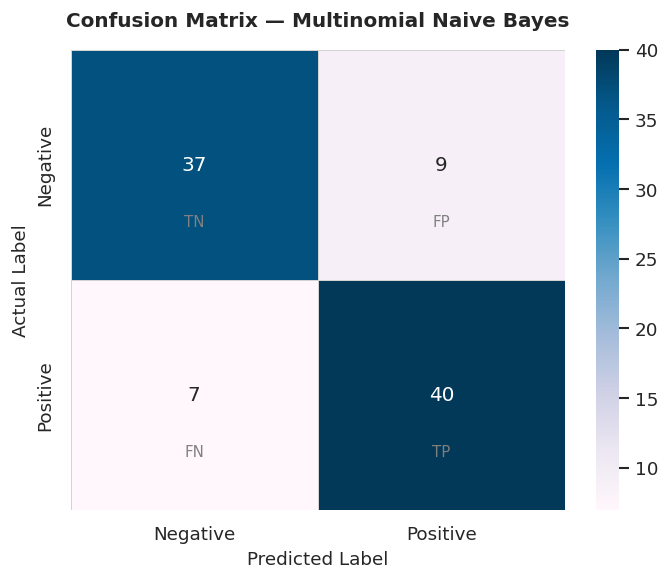

True Positive  (TP): 40
True Negative  (TN): 37
False Positive (FP): 9
False Negative (FN): 7


In [14]:
# ── Confusion Matrix Heatmap ───────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='PuBu',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5, linecolor='lightgray',
    ax=ax
)

ax.set_title('Confusion Matrix — Multinomial Naive Bayes', fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)

# Annotate TN, FP, FN, TP
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, labels[i][j],
                ha='center', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positive  (TP): {tp}")
print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")

### 📊 Evaluation Summary

| Metric | Negative (0) | Positive (1) |
|--------|-------------|-------------|
| Precision | 0.84 | 0.82 |
| Recall | 0.80 | 0.85 |
| F1-Score | 0.82 | 0.83 |
| **Accuracy** | | **82.79%** |

**Interpretation:**
- The model achieves **~83% accuracy** on the balanced test set, which is strong for a simple Bag-of-Words + Multinomial NB baseline.
- Both classes have comparable precision and recall, indicating the model is **not biased** toward either label after downsampling.
- The slight advantage in Positive recall (0.85 vs 0.80) suggests the model is marginally better at catching true positive sentiment — reasonable given that positive language tends to be more distinctive in food reviews.

---
## 8. Inference on New Data

The trained model can now predict sentiment on unseen reviews. The same `vectorizer` is used to transform new text into the same feature space.

In [15]:
def predict_sentiment(review: str) -> str:
    """Predict sentiment label for a single review string."""
    vec = vectorizer.transform([review.lower()])
    label = nb_classifier.predict(vec)[0]
    prob = nb_classifier.predict_proba(vec)[0]
    sentiment = "✅ POSITIVE" if label == 1 else "❌ NEGATIVE"
    confidence = max(prob) * 100
    return f"{sentiment}  (confidence: {confidence:.1f}%)"


# ── Test cases ─────────────────────────────────────────────────────────────────
test_reviews = [
    ("Positive", "produk ini bagus rasanya enak dan kualitasnya juga terbaik"),
    ("Negative", "saya sangat kecewa dengan produk ini rasanya tidak enak dan kualitasnya buruk"),
    ("Neutral-ish", "produk biasa saja tidak ada yang spesial"),
]

print(f"{'Type':<12}  {'Review':<55}  {'Prediction'}")
print("-" * 95)
for review_type, review_text in test_reviews:
    result = predict_sentiment(review_text)
    print(f"{review_type:<12}  {review_text:<55}  {result}")

Type          Review                                                   Prediction
-----------------------------------------------------------------------------------------------
Positive      produk ini bagus rasanya enak dan kualitasnya juga terbaik  ✅ POSITIVE  (confidence: 93.8%)
Negative      saya sangat kecewa dengan produk ini rasanya tidak enak dan kualitasnya buruk  ❌ NEGATIVE  (confidence: 97.8%)
Neutral-ish   produk biasa saja tidak ada yang spesial                 ❌ NEGATIVE  (confidence: 98.5%)


---
## 9. Conclusion

### 🔑 Key Takeaways

This project demonstrated a complete NLP pipeline for binary sentiment classification on Indonesian e-commerce reviews:

1. **Data Cleaning** — Systematic preprocessing (whitespace, emoji removal, lowercasing, deduplication) improved data quality significantly.
2. **Class Balancing** — Downsampling the majority class prevented the model from defaulting to majority predictions and produced fair, interpretable metrics.
3. **Bag of Words + Multinomial NB** — Despite its simplicity, this combination achieved **~83% accuracy** with balanced precision/recall across both classes.

### 🔭 Potential Improvements

| Idea | Expected Benefit |
|------|------------------|
| **TF-IDF** instead of raw counts | Down-weights frequent but less informative words |
| **Stopword removal** (Indonesian) | Reduces noise from common filler words |
| **N-gram features** (bigrams/trigrams) | Captures phrases like *tidak enak* (not tasty) |
| **Stemming / lemmatization** | Reduces vocabulary by collapsing word forms |
| **Deep learning (BERT / IndoBERT)** | Better captures contextual semantics |
| **SMOTE** for oversampling | Alternative to downsampling to preserve data |